# Medidas de Dispersión

Estas medidas indican cuán dispersos o agrupados están los datos alrededor de la medida de centralización: 
- Varianza (Mide la dispersión de los datos en relación con la media.). 
- Desviación estándar (Es la raíz cuadrada de la varianza y proporciona una medida de dispersión en la misma unidad que los datos)
-  Rango (diferencia entre el valor máximo y el valor mínimo en el conjunto de datos.)
-  Coeficiente de variación: Es la relación entre la desviación estándar y la media, expresada como un porcentaje. Es útil para comparar la dispersión entre conjuntos de datos con diferentes unidades o medias.)
-  Rango intercuartílico (IQR) (Es la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1). Mide la dispersión de la mitad central de los datos y es menos sensible a los valores atípicos.)



In [6]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np

# Visualización
# ------------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("./files/bank-additional_clean.csv", index_col = 0)

df.head()

,income,kidhome,teenhome,dt_customer,numwebvisitsmonth,id,age,job,marital,education,default,housing,loan,contact,duration,campaign,pdays,previous,poutcome,empvarrate,conspriceidx,consconfidx,euribor3m,nremployed,y,date,latitude,longitude,contact_month,contact_year,age_cat
0,161770,1,0,2012-04-04,29,089b39d8-e4d0-461b-87d4-814d71e0e079,NaN,housemaid,married,basic 4y,No,No,No,telephone,261,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,2-agosto-2019,41.495,-71.233,agosto,2019.0,Adultos mayores
1,85477,1,1,2012-12-30,7,e9d37224-cb6f-4942-98d7-46672963d097,57.0,services,married,high school,NaN,No,No,telephone,149,1,NaN,0,nonexistent,1.1,93.994,-36.4,NaN,5191,no,14-septiembre-2016,34.601,-83.923,septiembre,2016.0,Mediana edad
2,147233,1,1,2012-02-02,5,3f9f49b5-e410-4948-bf6e-f9244f04918b,37.0,services,married,high school,No,Si,No,telephone,226,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,15-febrero-2019,34.939,-94.847,febrero,2019.0,Adultos jóvenes
3,121393,1,2,2012-12-21,29,9991fafb-4447-451a-8be2-b0df6098d13e,40.0,admin.,married,basic 6y,No,No,No,telephone,151,1,NaN,0,nonexistent,1.1,93.994,-36.4,NaN,5191,no,29-noviembre-2015,49.041,-70.308,noviembre,2015.0,Mediana edad
4,63164,1,2,2012-06-20,20,eca60b76-70b6-4077-80ba-bc52e8ebb0eb,56.0,services,married,high school,No,No,Si,telephone,307,1,NaN,0,nonexistent,1.1,93.994,-36.4,NaN,5191,no,29-enero-2017,38.033,-104.463,enero,2017.0,Mediana edad


In [8]:
# Calculamos la varianza y la desviación estandard de 'income' y las comparamos con la media y mediana.

media_ingresos = df['income'].mean()
mediana_ingresos = df['income'].median()

varianza_ingresos = df['income'].var()
desv_std_ingresos = df['income'].std()

rango = df['income'].max() - df['income'].min()
cv_ingresos = desv_std_ingresos / media_ingresos * 100
IQR = df['income'].quantile(0.75) - df['income'].quantile(0.25) # mide la dispersión del 50% central de los datos. Se calcula como la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1).


print(f"La media de los ingresos de los clientes es: {np.round(media_ingresos, 2)}")
print(f"La mediana de los ingresos de los clientes es: {np.round(mediana_ingresos, 2)}")
print(f"La varianza  de los ingresos de los clientes es: {np.round(varianza_ingresos, 2)}")
print(f"La desviación estándar de los ingresos de los clientes es: {np.round(desv_std_ingresos, 2)}")
print(f"El rango de los ingresos de los clientes es: {np.round(rango, 2)}")
print(f"Coeficiente de Variación: {cv_ingresos:.2f}%")
print(f"Rango Intercuartílico: {IQR:.2f}")


La media de los ingresos de los clientes es: 93241.2
La mediana de los ingresos de los clientes es: 93050.5
La varianza  de los ingresos de los clientes es: 2550079937.2
La desviación estándar de los ingresos de los clientes es: 50498.32
El rango de los ingresos de los clientes es: 174961
Coeficiente de Variación: 54.16%
Rango Intercuartílico: 87134.50


**¿Cómo interpretamos todas las medidas que hemos visto a la vez?**

1. Nivel “típico” de ingresos
   - Media: 93,241.2
   - Mediana: 93,050.5
- La media y la mediana son muy parecidas (diferencia ~190.7, que es ~0.2% de la media). Esto sugiere que la distribución de ingresos está bastante centrada y no parece estar fuertemente sesgada por unos pocos valores extremadamente altos o bajos (al menos no lo suficiente como para separar mucho media y mediana).

1. Dispersión: los ingresos varían mucho
   - Desviación estándar: 50,498.32: Esto es grande en términos absolutos: los ingresos se separan bastante del valor central.
    - Coeficiente de variación (CV): 54.16%: Esto es muy alto. Significa que la desviación estándar equivale a ~54% del promedio. Interpretación práctica: hay mucha heterogeneidad entre clientes; los ingresos no son “parecidos”, sino muy variados.
**(Regla práctica: CV > 30% suele considerarse alta variabilidad; 54% es claramente alta.)**

1. Rango e IQR: presencia probable de extremos (o distribución muy extendida)
   - Rango: 174,961: La diferencia entre el ingreso mínimo y máximo es enorme.
   - IQR: 87,134.5 : El 50% central de los clientes (entre Q1 y Q3) ya cubre un tramo de ~87k, lo cual confirma que incluso la parte central está muy dispersa (no es solo “culpa” de 2 outliers).

Los clientes tienen un ingreso “típico” alrededor de 93k, y la distribución no muestra un sesgo fuerte (media≈mediana). Sin embargo, los ingresos son muy desiguales entre clientes: la variación es alta (CV 54%), el 50% central abarca ~87k, y el rango total es ~175k.

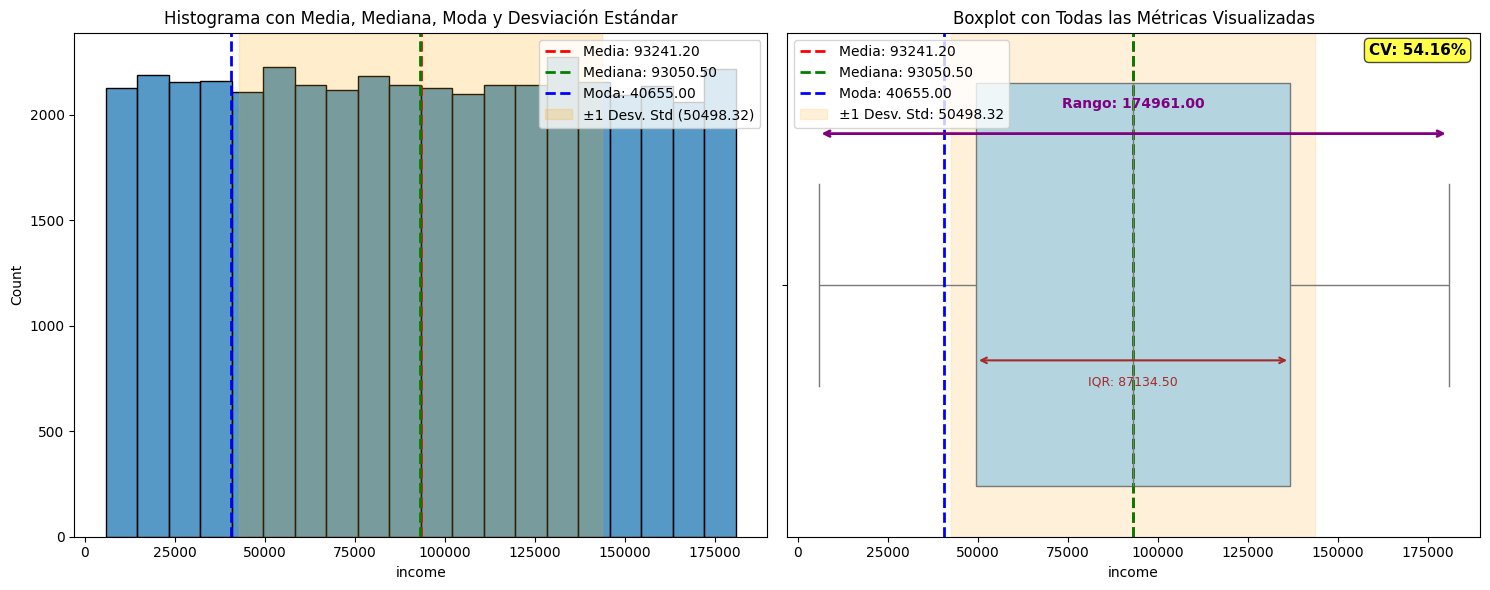

In [9]:
# Calcular métricas de tendencia central
media_ingresos = df['income'].mean()
mediana_ingresos = df['income'].median()
moda_ingresos = df['income'].mode()[0]

# Calcular métricas de dispersión
varianza_ingresos = df['income'].var()
desv_std_ingresos = df['income'].std()
rango_ingresos = df['income'].max() - df['income'].min()
cv_ingresos = (desv_std_ingresos / media_ingresos) * 100
q1 = df['income'].quantile(0.25)
q3 = df['income'].quantile(0.75)

# Visualizaciones para 'income'
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Visualización: Histograma con la media y desviación estándar
sns.histplot(df['income'], bins=20, ax=axes[0])
axes[0].axvline(media_ingresos, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_ingresos:.2f}')
axes[0].axvline(mediana_ingresos, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_ingresos:.2f}')
axes[0].axvline(moda_ingresos, color='blue', linestyle='dashed', linewidth=2, label=f'Moda: {moda_ingresos:.2f}')

# Añadir área sombreada para ±1 desviación estándar
axes[0].axvspan(media_ingresos - desv_std_ingresos, media_ingresos + desv_std_ingresos, 
                alpha=0.2, color='orange', label=f'±1 Desv. Std ({desv_std_ingresos:.2f})')

axes[0].legend()
axes[0].set_title('Histograma con Media, Mediana, Moda y Desviación Estándar')

# Crear el Boxplot con anotaciones visuales
sns.boxplot(x=df['income'], ax=axes[1], color='lightblue')

# Dibujar líneas para la media, mediana y moda
axes[1].axvline(media_ingresos, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media_ingresos:.2f}')
axes[1].axvline(mediana_ingresos, color='green', linestyle='dashed', linewidth=2, label=f'Mediana: {mediana_ingresos:.2f}')
axes[1].axvline(moda_ingresos, color='blue', linestyle='dashed', linewidth=2, label=f'Moda: {moda_ingresos:.2f}')

# Visualizar el RANGO con flechas
axes[1].annotate('', xy=(df['income'].max(), -0.3), xytext=(df['income'].min(), -0.3),
                arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
axes[1].text((df['income'].min() + df['income'].max())/2, -0.35, 
            f'Rango: {rango_ingresos:.2f}', 
            ha='center', color='purple', fontsize=10, weight='bold')

# Visualizar la DESVIACIÓN ESTÁNDAR con área sombreada
axes[1].axvspan(media_ingresos - desv_std_ingresos, media_ingresos + desv_std_ingresos, 
                alpha=0.15, color='orange', label=f'±1 Desv. Std: {desv_std_ingresos:.2f}')

# Anotar el IQR (relacionado con varianza)
iqr = q3 - q1
axes[1].annotate('', xy=(q3, 0.15), xytext=(q1, 0.15),
                arrowprops=dict(arrowstyle='<->', color='brown', lw=1.5))
axes[1].text((q1 + q3)/2, 0.2, f'IQR: {iqr:.2f}', 
            ha='center', color='brown', fontsize=9)

# Añadir CV como texto
axes[1].text(0.98, 0.98, f'CV: {cv_ingresos:.2f}%', 
            transform=axes[1].transAxes,
            fontsize=11,
            verticalalignment='top',
            horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
            weight='bold')

axes[1].legend(loc='upper left')
axes[1].set_title('Boxplot con Todas las Métricas Visualizadas')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [10]:
# Calculamos la varianza y la desviación estandard de 'age' y las comparamos con la media, mediana y moda.

varianza_age = df['age'].var()
desv_std_age = df['age'].std()

media_age = df['age'].mean()
mediana_age = df['age'].median()

rango = df['age'].max() - df['age'].min()

CV_edad = desv_std_age / media_age * 100


IQR_edad = df['age'].quantile(0.75) - df['age'].quantile(0.25)

print(f"La media de la edad de los clientes es: {np.round(media_age, 2)}")
print(f"La mediana de edad de los clientes es: {np.round(mediana_age, 2)}")
print(f"La varianza de la edad de los clientes es: {np.round(varianza_age, 2)}")
print(f"La desviación estándar de la edad de los clientes es: {np.round(desv_std_age, 2)}")
print(f"El rango de la edad de los clientes es: {np.round(rango, 2)}")
print(f"Coeficiente de Variación de la edad: {CV_edad:.2f}%")
print(f"Rango Intercuartílico de la edad: {IQR_edad:.2f}")

La media de la edad de los clientes es: 39.98
La mediana de edad de los clientes es: 38.0
La varianza de la edad de los clientes es: 108.95
La desviación estándar de la edad de los clientes es: 10.44
El rango de la edad de los clientes es: 81.0
Coeficiente de Variación de la edad: 26.11%
Rango Intercuartílico de la edad: 15.00


In [14]:
df['age'].quantile(0.25)

np.float64(32.0)

**¿Cómo interpretamos todas las medidas que hemos visto a la vez?**


1. **Media (Promedio): 39.98**
   - La media es el promedio de todas las edades en el conjunto de datos. Se calcula sumando todas las edades y dividiendo por el número total de clientes.
   - En este caso, la media de edad nos da una idea general de cuál es la "edad promedio" en el conjunto de clientes.

2. **Mediana (Valor del Medio): 38**
   - La mediana es el valor que se encuentra justo en el medio de la lista de edades cuando estas se ordenan de menor a mayor.
   - La mediana es útil cuando hay valores extremadamente altos o bajos que pueden afectar la media. En este caso, significa que la mitad de los clientes tienen edades iguales o inferiores a 38 y la otra mitad tiene edades iguales o superiores a este valor.

3. **Varianza: 108.95**
   - La varianza es una medida de la dispersión de las edades alrededor de la media. Es una medida de cuán dispersas están las edades en el conjunto de datos.
   - En este caso, una varianza de 108.95 indica que las edades tienden a variar relativamente mucho alrededor de la media. Cuanto mayor sea la varianza, mayor será la dispersión de las edades alrededor de la media.

4. **Desviación Estándar: 10.44**
   - La desviación estándar es simplemente la raíz cuadrada de la varianza. Es una medida de dispersión que tiene las mismas unidades que la variable original (en este caso, años).
   - Una desviación estándar más baja indica que las edades tienden a estar más cerca de la media, mientras que una desviación estándar más alta indica que las edades están más dispersas alrededor de la media.
5. **Rango: 61**
   - El rango es la diferencia entre la edad máxima y la edad mínima en el conjunto de datos.
   - En este caso, un rango de 61 indica que hay una amplia variedad de edades entre los clientes, desde el más joven hasta el más viejo.
6. **Coeficiente de Variación: 26.12%**
   - El coeficiente de variación (CV) es una medida relativa de dispersión que expresa la desviación estándar como un porcentaje de la media.
   - Un CV del 26.12% indica que la desviación estándar es aproximadamente el 26.12% de la media, lo que sugiere una moderada variabilidad en las edades de los clientes.
     - **Rango Intercuartílico (IQR): 15**
   - El rango intercuartílico (IQR) mide la dispersión de la mitad central de los datos, es decir, la diferencia entre el tercer cuartil (Q3) y el primer cuartil (Q1).
   - Un IQR de 15 indica que la mitad central de las edades de los clientes abarca un rango de 15 años, lo que sugiere que la mayoría de las edades están relativamente concentradas en ese rango.

En resumen, la media nos da el valor promedio, la mediana nos muestra el valor del medio, la varianza nos dice cuánto se dispersan las edades, y la desviación estándar nos proporciona una medida de dispersión que tiene las mismas unidades que la variable original. Cada una de estas medidas aporta información diferente sobre la distribución de las edades en el conjunto de datos.

## ¿Cuando usar varianza o std?:
- Desviación Estándar es más intuitiva y fácil de interpretar. Úsala para entender la dispersión en un análisis exploratorio.
- Varianza es más útil en cálculos estadísticos avanzados y cuando necesitas comparar la variabilidad entre conjuntos de datos.